In [1]:
# @title 1. Install & Login
!pip install torch_geometric sentence-transformers neo4j pandas scikit-learn wandb matplotlib seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 23.5 MB/s eta 0:00:00


In [2]:
import os
import random
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
from neo4j import GraphDatabase
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Login
wandb.login()

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Ready. Using {device}")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 Ready. Using cuda


In [3]:
# @title 2. Build Rich Graph & Smart Labels

# --- CREDENTIALS ---
URI = "neo4j+s://ccf24920.databases.neo4j.io"
AUTH = ("neo4j", "YHXssrChTu3r3FinSLYiNVUBhXoUEjcUDM-h0ERxD1E")
driver = GraphDatabase.driver(URI, auth=AUTH)


In [8]:
GraphDatabase.driver(URI, auth=AUTH)

def load_rich_data():
    with driver.session() as session:
        # A. Fetch Nodes with Context
        print(" Fetching Nodes & Context...")
        node_query = """
        MATCH (a:Article)
        OPTIONAL MATCH (p:Part)-[:HAS_ARTICLE]->(a)
        OPTIONAL MATCH (a)-[:GOVERNS]->(i:Institution)
        OPTIONAL MATCH (a)-[:TAGGED]->(t:Tag)
        RETURN
            a.id as id,
            a.text as text,
            a.title as title,
            p.id as part_id,
            labels(a) as neo_labels,
            collect(i.name) as institutions,
            collect(t.name) as tags
        """
        df_nodes = pd.DataFrame([r.data() for r in session.run(node_query)])

        # B. Fetch Edges: Citations AND Structural Neighbors
        # This fixes the "Sparse Graph" problem
        print(" Fetching Edges (Citations + Structure)...")
        edge_query = """
        // 1. Citations
        MATCH (s:Article)-[:REFERENCES]->(t:Article)
        RETURN s.id as source, t.id as target
        UNION
        // 2. Structural Neighbors (Same Part) -> Implicit Connection
        MATCH (s:Article)<-[:HAS_ARTICLE]-(p:Part)-[:HAS_ARTICLE]->(t:Article)
        WHERE s.id < t.id // Avoid duplicates
        RETURN s.id as source, t.id as target
        """
        df_edges = pd.DataFrame([r.data() for r in session.run(edge_query)])

    return df_nodes, df_edges

df_nodes, df_edges = load_rich_data()



 Fetching Nodes & Context...
 Fetching Edges (Citations + Structure)...


In [9]:
# --- SMART LABELING (Your Logic) ---
labels = []
categories = []
class_names = ["Rights", "Judiciary", "Federalism", "Governance", "Other"]

In [10]:
for _, row in df_nodes.iterrows():
  text = (str(row['text']) + " " + str(row.get('title', ''))).lower()
  neo_labels = row['neo_labels']
  insts = row['institutions']
  tags = row['tags']

  # Priority 1: Structure
  if "FundamentalRight" in neo_labels:
      labels.append(0); categories.append("Rights")
  elif any(i in insts for i in ["Supreme Court", "High Court"]):
      labels.append(1); categories.append("Judiciary")
  # Priority 2: Keywords
  elif any(x in text for x in ["province", "local level", "federation"]):
      labels.append(2); categories.append("Federalism")
  elif any(x in text for x in ["president", "minister", "parliament", "election"]):
      labels.append(3); categories.append("Governance")
  # Priority 3: Text Fallback
  elif "right" in text and "freedom" in text:
      labels.append(0); categories.append("Rights")
  elif "court" in text or "judicial" in text:
      labels.append(1); categories.append("Judiciary")
  else:
      labels.append(4); categories.append("Other")

df_nodes['label'] = labels


In [11]:
# --- PYG DATA CONSTRUCTION ---
print("Generating Features (SBERT)...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
node_features = embedder.encode(df_nodes['text'].tolist(), show_progress_bar=True)

Generating Features (SBERT)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

In [12]:
# Map IDs
id_map = {id: i for i, id in enumerate(df_nodes['id'])}
src = [id_map[x] for x in df_edges['source'] if x in id_map]
dst = [id_map[x] for x in df_edges['target'] if x in id_map]

In [13]:
# Create Tensors
x = torch.tensor(node_features, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

In [14]:
# Undirected graph (A<->B) works better for GCN classification
edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

In [15]:
# Calculate Class Weights (Inverse Frequency)
class_counts = np.bincount(y.numpy())
class_weights = 1. / class_counts
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f" Class Weights: {class_weights}")

 Class Weights: tensor([0.0130, 0.0263, 0.0526, 0.0132, 0.0089], device='cuda:0')


In [16]:
# Splits (Stratified)
indices = np.arange(data.num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.25, stratify=labels, random_state=SEED)
train_idx, val_idx = train_test_split(train_idx, test_size=0.15, stratify=np.array(labels)[train_idx], random_state=SEED)

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

data.train_mask[train_idx] = True
data.val_mask[val_idx] = True
data.test_mask[test_idx] = True

data = data.to(device)
print(f" Graph Ready: {data.num_nodes} nodes, {data.num_edges} edges.")

 Graph Ready: 322 nodes, 4940 edges.


In [17]:
# @title 3. Define & Train GCN

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(data.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 5) # 5 Classes

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights) # Use Weights!

In [10]:
print("Total nodes:", data.num_nodes)
print("Train:", data.train_mask.sum().item())
print("Test:", data.test_mask.sum().item())
print("Class counts in test:", np.bincount(data.y[data.test_mask].cpu().numpy()))

Total nodes: 308
Train: 231
Test: 77
Class counts in test: [20  9  3 16 29]


In [19]:
# Evaluation
model.eval()
out = model(data.x, data.edge_index)
pred = out.argmax(dim=1)

In [20]:
# Get Test Data
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()

In [21]:
# 1. Classification Report
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
wandb.log({"classification_report": wandb.Table(dataframe=pd.DataFrame(report_dict).T)})


 Classification Report:
              precision    recall  f1-score   support

      Rights       0.82      0.95      0.88        19
   Judiciary       0.57      0.80      0.67        10
  Federalism       0.50      0.40      0.44         5
  Governance       0.83      0.79      0.81        19
       Other       0.70      0.57      0.63        28

    accuracy                           0.73        81
   macro avg       0.68      0.70      0.69        81
weighted avg       0.73      0.73      0.72        81



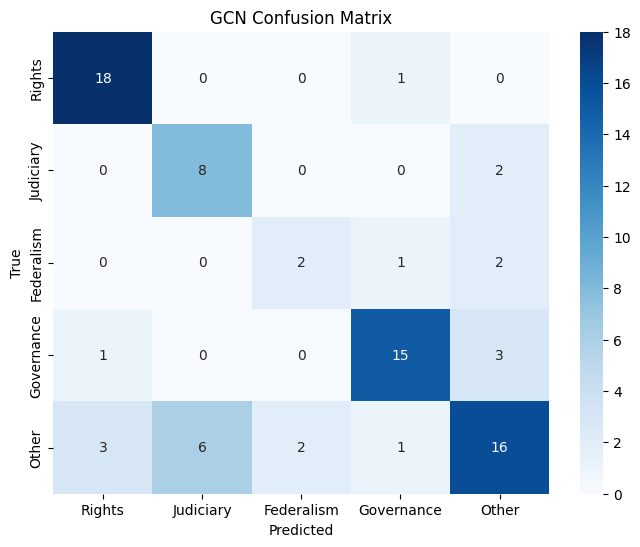

In [22]:
# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('GCN Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig("cm_gcn.png", bbox_inches='tight', dpi=120)
wandb.log({"confusion_matrix": wandb.Image("cm_gcn.png")})
plt.show()
plt.close()


In [23]:
import time

# Synchronize CUDA for accurate timing if using GPU
if torch.cuda.is_available(): torch.cuda.synchronize()

start_time = time.time()

# The actual Inference Step
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

if torch.cuda.is_available(): torch.cuda.synchronize()
end_time = time.time()

In [24]:
# Calculate Latency
total_time_ms = (end_time - start_time) * 1000
per_node_ms = total_time_ms / data.num_nodes

print(f"\n INFERENCE COST:")
print(f"   Total Time: {total_time_ms:.2f} ms")
print(f"   Per Node:   {per_node_ms:.4f} ms")


 INFERENCE COST:
   Total Time: 7.45 ms
   Per Node:   0.0231 ms


In [25]:
# --- C. METRICS CALCULATION ---
# Extract Test Data
y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()
y_score = out[data.test_mask].softmax(dim=1).cpu().numpy() # Probas

In [26]:
# 1. Macro F1 (The Metric you requested)
macro_f1 = f1_score(y_true, y_pred, average='macro')
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
acc = (y_pred == y_true).mean()

print(f"\n METRICS:")
print(f"   Macro F1:   {macro_f1:.4f}")
print(f"   Weighted F1:{weighted_f1:.4f}")
print(f"   Accuracy:   {acc:.4f}")


 METRICS:
   Macro F1:   0.6855
   Weighted F1:0.7228
   Accuracy:   0.7284


In [27]:
# --- D. LOGGING TO W&B ---

# Log Scalars
wandb.log({
    "test_macro_f1": macro_f1,
    "test_weighted_f1": weighted_f1,
    "test_accuracy": acc,
    "inference_time_ms": total_time_ms,
    "inference_time_per_node_ms": per_node_ms,
    "classification_report": wandb.Table(dataframe=pd.DataFrame(report_dict).T)
})

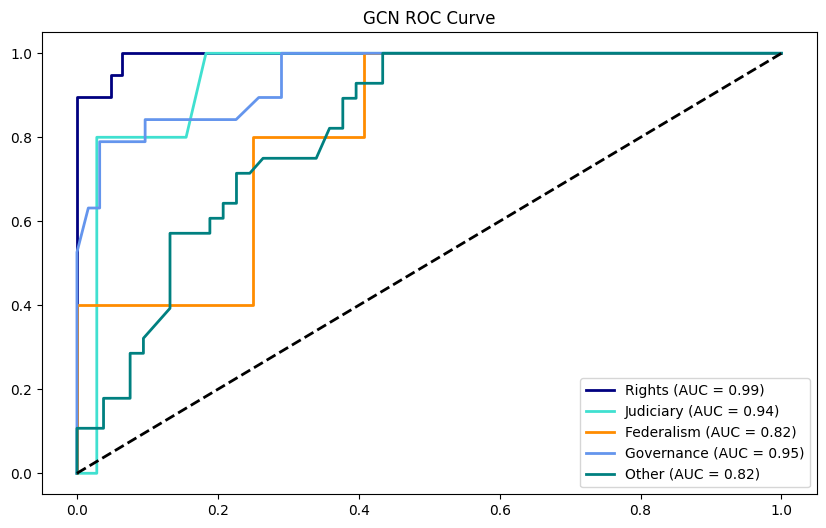

In [29]:
from sklearn.metrics import roc_curve, auc

# 3. ROC Curves
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4])
y_score = out[data.test_mask].softmax(dim=1).detach().cpu().numpy()
n_classes = y_true_bin.shape[1]

fpr, tpr, roc_auc = dict(), dict(), dict()
plt.figure(figsize=(10, 6))
colors = cycle(['navy', 'turquoise', 'darkorange', 'cornflowerblue', 'teal'])

for i, color in zip(range(n_classes), colors):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('GCN ROC Curve')
plt.legend(loc="lower right")
plt.savefig("roc_gcn.png", bbox_inches='tight', dpi=120)
wandb.log({"roc_curve": wandb.Image("roc_gcn.png")})
plt.show()
plt.close()


In [ ]:
# @title 4. GraphSAGE Optimization Experiment
!pip install torch_geometric sentence-transformers neo4j pandas scikit-learn wandb -q

In [30]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import wandb
from neo4j import GraphDatabase

# --- SETUP ---
wandb.login()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)



wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [31]:
# --- CREDENTIALS ---
URI = "neo4j+s://ccf24920.databases.neo4j.io"
AUTH = ("neo4j", "YHXssrChTu3r3FinSLYiNVUBhXoUEjcUDM-h0ERxD1E")
driver = GraphDatabase.driver(URI, auth=AUTH)

In [32]:
def get_optimized_data():
    with driver.session() as session:
        # Nodes + Context
        query_nodes = """
        MATCH (a:Article)
        OPTIONAL MATCH (p:Part)-[:HAS_ARTICLE]->(a)
        OPTIONAL MATCH (a)-[:GOVERNS]->(i:Institution)
        OPTIONAL MATCH (a)-[:TAGGED]->(t:Tag)
        RETURN a.id as id, a.text as text, a.title as title, labels(a) as labels,
               collect(distinct i.name) as institutions, collect(distinct t.name) as tags
        """
        df_nodes = pd.DataFrame([r.data() for r in session.run(query_nodes)])

        # Edges (Rich: Citations + Same Part)
        query_edges = """
        MATCH (s:Article)-[:REFERENCES]->(t:Article) RETURN s.id as source, t.id as target
        UNION
        MATCH (s:Article)<-[:HAS_ARTICLE]-(p:Part)-[:HAS_ARTICLE]->(t:Article)
        WHERE s.id < t.id
        RETURN s.id as source, t.id as target
        """
        df_edges = pd.DataFrame([r.data() for r in session.run(query_edges)])

    # --- ADVANCED LABELING (Your Logic) ---
    labels = []
    class_names = ["Rights", "Judiciary", "Federalism", "Governance", "Other"]

    for _, row in df_nodes.iterrows():
        text = (str(row['text']) + " " + str(row.get('title', ''))).lower()
        neo = row['labels']; insts = row['institutions']; tags = row['tags']

        if "FundamentalRight" in neo or any(t in tags for t in ["Women", "Dalit"]):
            labels.append(0) # Rights
        elif any(i in insts for i in ["Supreme Court", "High Court"]) or "court" in text:
            labels.append(1) # Judiciary
        elif any(k in text for k in ["province", "federation"]):
            labels.append(2) # Federalism
        elif any(k in text for k in ["president", "parliament", "minister"]):
            labels.append(3) # Gov
        else:
            labels.append(4) # Other

    # --- FEATURES ---
    print("Generating SBERT...")
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    x = torch.tensor(embedder.encode(df_nodes['text'].tolist()), dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)

    # --- GRAPH ---
    id_map = {id: i for i, id in enumerate(df_nodes['id'])}
    src = [id_map[x] for x in df_edges['source'] if x in id_map]
    dst = [id_map[x] for x in df_edges['target'] if x in id_map]
    edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long) # Undirected

    return Data(x=x, edge_index=edge_index, y=y).to(device), class_names

data, class_names = get_optimized_data()



Generating SBERT...


In [33]:
# Splits (Stratified)
indices = np.arange(data.num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.25, stratify=data.y.cpu().numpy(), random_state=SEED)
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True; data.test_mask[test_idx] = True


In [34]:
# --- GRAPHSAGE MODEL ---
class GraphSAGE(torch.nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # SAGEConv aggregates neighbors (Mean/Max/LSTM)
        self.conv1 = SAGEConv(384, hidden_dim, aggr='mean')
        self.conv2 = SAGEConv(hidden_dim, 5)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x) # ELU often works better than ReLU for text
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return x


In [35]:

model = GraphSAGE(hidden_dim=128).to(device) # Increased Hidden Dim
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Calculate Class Weights to handle imbalance
class_counts = torch.bincount(data.y)
weights = 1. / class_counts.float()
weights = weights / weights.sum() # Normalize
criterion = torch.nn.CrossEntropyLoss(weight=weights)


In [36]:
def train_sage():
    run = wandb.init(project="Week-5", name="day4-graphsage-opt", config={"model":"GraphSAGE"})

    # Train
    model.train()
    for epoch in range(300): # More epochs
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()

    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print("\n GraphSAGE Results:")
    print(f"Macro F1: {macro_f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    wandb.log({"macro_f1": macro_f1})
    run.finish()

In [37]:
train_sage()

inference_time_ms,▁
inference_time_per_node_ms,▁
test_accuracy,▁
test_macro_f1,▁
test_weighted_f1,▁
train_loss,█▂▁▁▁▁▁▁▁▁
inference_time_ms,7.45296
inference_time_per_node_ms,0.02315
test_accuracy,0.7284
test_macro_f1,0.68548
test_weighted_f1,0.72279



 GraphSAGE Results:
Macro F1: 0.7815
              precision    recall  f1-score   support

      Rights       0.75      0.90      0.82        20
   Judiciary       0.80      0.89      0.84         9
  Federalism       0.50      1.00      0.67         3
  Governance       0.79      0.94      0.86        16
       Other       0.94      0.59      0.72        29

    accuracy                           0.79        77
   macro avg       0.76      0.86      0.78        77
weighted avg       0.83      0.79      0.79        77



macro_f1,▁
macro_f1,0.7815


In [8]:
# @title 4. Train GraphSAGE & Plot Metrics (CM + ROC)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, f1_score
from itertools import cycle
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv

# Added for self-containment of data loading
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np
from neo4j import GraphDatabase
from torch_geometric.data import Data # Need Data object for self-contained data creation
import wandb
from sklearn.model_selection import train_test_split # Needed for data splits

# Define device here for self-contained execution
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reproducibility (added for self-containment)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- CREDENTIALS (Copied for self-containment) ---
URI = "neo4j+s://ccf24920.databases.neo4j.io"
AUTH = ("neo4j", "YHXssrChTu3r3FinSLYiNVUBhXoUEjcUDM-h0ERxD1E")
driver = GraphDatabase.driver(URI, auth=AUTH)

# --- get_optimized_data function (Copied for self-containment) ---
def get_optimized_data():
    with driver.session() as session:
        # Nodes + Context
        query_nodes = """
        MATCH (a:Article)
        OPTIONAL MATCH (p:Part)-[:HAS_ARTICLE]->(a)
        OPTIONAL MATCH (a)-[:GOVERNS]->(i:Institution)
        OPTIONAL MATCH (a)-[:TAGGED]->(t:Tag)
        RETURN a.id as id, a.text as text, a.title as title, labels(a) as labels,
               collect(distinct i.name) as institutions, collect(distinct t.name) as tags
        """
        df_nodes = pd.DataFrame([r.data() for r in session.run(query_nodes)])

        # Edges (Rich: Citations + Same Part)
        query_edges = """
        MATCH (s:Article)-[:REFERENCES]->(t:Article) RETURN s.id as source, t.id as target
        UNION
        MATCH (s:Article)<-[:HAS_ARTICLE]-(p:Part)-[:HAS_ARTICLE]->(t:Article)
        WHERE s.id < t.id
        RETURN s.id as source, t.id as target
        """
        df_edges = pd.DataFrame([r.data() for r in session.run(query_edges)])

    # --- ADVANCED LABELING (Your Logic) ---
    labels = []
    class_names_local = ["Rights", "Judiciary", "Federalism", "Governance", "Other"]

    for _, row in df_nodes.iterrows():
        text = (str(row['text']) + " " + str(row.get('title', ''))).lower()
        neo = row['labels']; insts = row['institutions']; tags = row['tags']

        if "FundamentalRight" in neo or any(t in tags for t in ["Women", "Dalit"]):
            labels.append(0) # Rights
        elif any(i in insts for i in ["Supreme Court", "High Court"]) or "court" in text:
            labels.append(1) # Judiciary
        elif any(k in text for k in ["province", "federation"]):
            labels.append(2) # Federalism
        elif any(k in text for k in ["president", "parliament", "minister"]):
            labels.append(3) # Gov
        else:
            labels.append(4) # Other

    # --- FEATURES ---
    print("Generating SBERT...")
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    x = torch.tensor(embedder.encode(df_nodes['text'].tolist()), dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)

    # --- GRAPH ---
    id_map = {id: i for i, id in enumerate(df_nodes['id'])}
    src = [id_map[x] for x in df_edges['source'] if x in id_map]
    dst = [id_map[x] for x in df_edges['target'] if x in id_map]
    edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long) # Undirected

    return Data(x=x, edge_index=edge_index, y=y).to(device), class_names_local

# Call get_optimized_data to get 'data' and 'class_names'
data, class_names = get_optimized_data()

# Splits (Stratified) - copied for self-containment
indices = np.arange(data.num_nodes)
train_idx, test_idx = train_test_split(indices, test_size=0.25, stratify=data.y.cpu().numpy(), random_state=SEED)
data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[train_idx] = True; data.test_mask[test_idx] = True

# --- GRAPHSAGE MODEL (Moved here for self-containment) ---

class GraphSAGE(torch.nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.conv1 = SAGEConv(data.num_features, hidden_dim, aggr="mean")
        self.conv2 = SAGEConv(hidden_dim, len(class_names))

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.4, training=self.training)
        x = self.conv2(x, edge_index)
        return x


model = GraphSAGE(hidden_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
class_counts = torch.bincount(data.y)
class_weights = (1.0 / class_counts.float()).to(device)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

run = wandb.init(
    project="Week-5",
    name="day4-graphsage-fixed",
    config={"model": "GraphSAGE", "hidden_dim": 128}
)

# ---- TRAIN ----
model.train()
for epoch in range(300):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        wandb.log({"train_loss": loss.item()})

# ---- EVAL ----
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    probas = F.softmax(out, dim=1)

y_true = data.y[data.test_mask].cpu().numpy()
y_pred = pred[data.test_mask].cpu().numpy()
y_score = probas[data.test_mask].cpu().numpy()

macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
acc = (y_true == y_pred).mean()

print("\nGraphSAGE Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

print("\nMETRICS:")
print(f"Macro F1:   {macro_f1:.4f}")
print(f"Weighted F1:{weighted_f1:.4f}")
print(f"Accuracy:   {acc:.4f}")

# ---- INFERENCE COST ----
if torch.cuda.is_available():
    torch.cuda.synchronize()

start = time.time()
with torch.no_grad():
    _ = model(data.x, data.edge_index)

if torch.cuda.is_available():
    torch.cuda.synchronize()

total_ms = (time.time() - start) * 1000
per_node_ms = total_ms / data.num_nodes

print("\nINFERENCE COST:")
print(f"Total Time: {total_ms:.2f} ms")
print(f"Per Node:   {per_node_ms:.4f} ms")

wandb.log({
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "accuracy": acc,
    "inference_ms": total_ms,
    "per_node_ms": per_node_ms
})

run.finish()

Generating SBERT...



GraphSAGE Classification Report:
              precision    recall  f1-score   support

      Rights       0.75      0.90      0.82        20
   Judiciary       0.80      0.89      0.84         9
  Federalism       0.50      1.00      0.67         3
  Governance       0.79      0.94      0.86        16
       Other       0.94      0.59      0.72        29

    accuracy                           0.79        77
   macro avg       0.76      0.86      0.78        77
weighted avg       0.83      0.79      0.79        77


METRICS:
Macro F1:   0.7815
Weighted F1:0.7875
Accuracy:   0.7922

INFERENCE COST:
Total Time: 2.70 ms
Per Node:   0.0088 ms


accuracy,▁
inference_ms,▁
macro_f1,▁
per_node_ms,▁
train_loss,█▁▁▁▁▁
weighted_f1,▁
accuracy,0.79221
inference_ms,2.70486
macro_f1,0.7815
per_node_ms,0.00878
train_loss,0.01679


In [9]:
print("Total nodes:", data.num_nodes)
print("Train:", data.train_mask.sum().item())
print("Test:", data.test_mask.sum().item())
print("Class counts in test:", np.bincount(data.y[data.test_mask].cpu().numpy()))

Total nodes: 308
Train: 231
Test: 77
Class counts in test: [20  9  3 16 29]
